# Questão 2

Avaliação do efeito do tamanho da DFT e do zero-padding para o sinal
`x(t) = sin(2πt) + sin(2.02πt)`, amostrado com `fs = 10 Hz`.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()

def find_repo_root(start_path):
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'data').exists() and (candidate / 'pratica_4').exists():
            return candidate
    raise FileNotFoundError(
        'Repositorio nao encontrado. Execute o notebook dentro da pasta do projeto.'
    )

REPO_ROOT = find_repo_root(CWD)


In [2]:
def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))



In [3]:
fs = 10.0

def x_t(t):
    return np.sin(2 * np.pi * t) + np.sin(2.02 * np.pi * t)

def spectrum_hz(signal, fs, nfft=None):
    if nfft is None:
        nfft = len(signal)
    X = np.fft.rfft(signal, n=nfft)
    f = np.fft.rfftfreq(nfft, d=1 / fs)
    return f, np.abs(X)

n64 = np.arange(64)
x64 = x_t(n64 / fs)

n128 = np.arange(128)
x128 = x_t(n128 / fs)

configs = [
    ('64 amostras', x64, 64),
    ('64 amostras + 64 zeros', x64, 128),
    ('128 amostras reais', x128, 128),
    ('128 amostras + 128 zeros', x128, 256),
    ('128 amostras + 384 zeros', x128, 512),
]

rows = []
spectra = {}
for label, sig, nfft in configs:
    f, mag = spectrum_hz(sig, fs, nfft=nfft)
    spectra[label] = (f, mag)
    rows.append(
        {
            'Configuracao': label,
            'Amostras reais': len(sig),
            'N da DFT': nfft,
            'Resolucao espectral (Hz)': fs / nfft,
        }
    )

display_rows(rows, float_digits=8)


Configuracao             | Amostras reais | N da DFT | Resolucao espectral (Hz)
-------------------------+----------------+----------+-------------------------
64 amostras              | 64             | 64       | 0.15625000              
64 amostras + 64 zeros   | 64             | 128      | 0.07812500              
128 amostras reais       | 128            | 128      | 0.07812500              
128 amostras + 128 zeros | 128            | 256      | 0.03906250              
128 amostras + 384 zeros | 128            | 512      | 0.01953125              


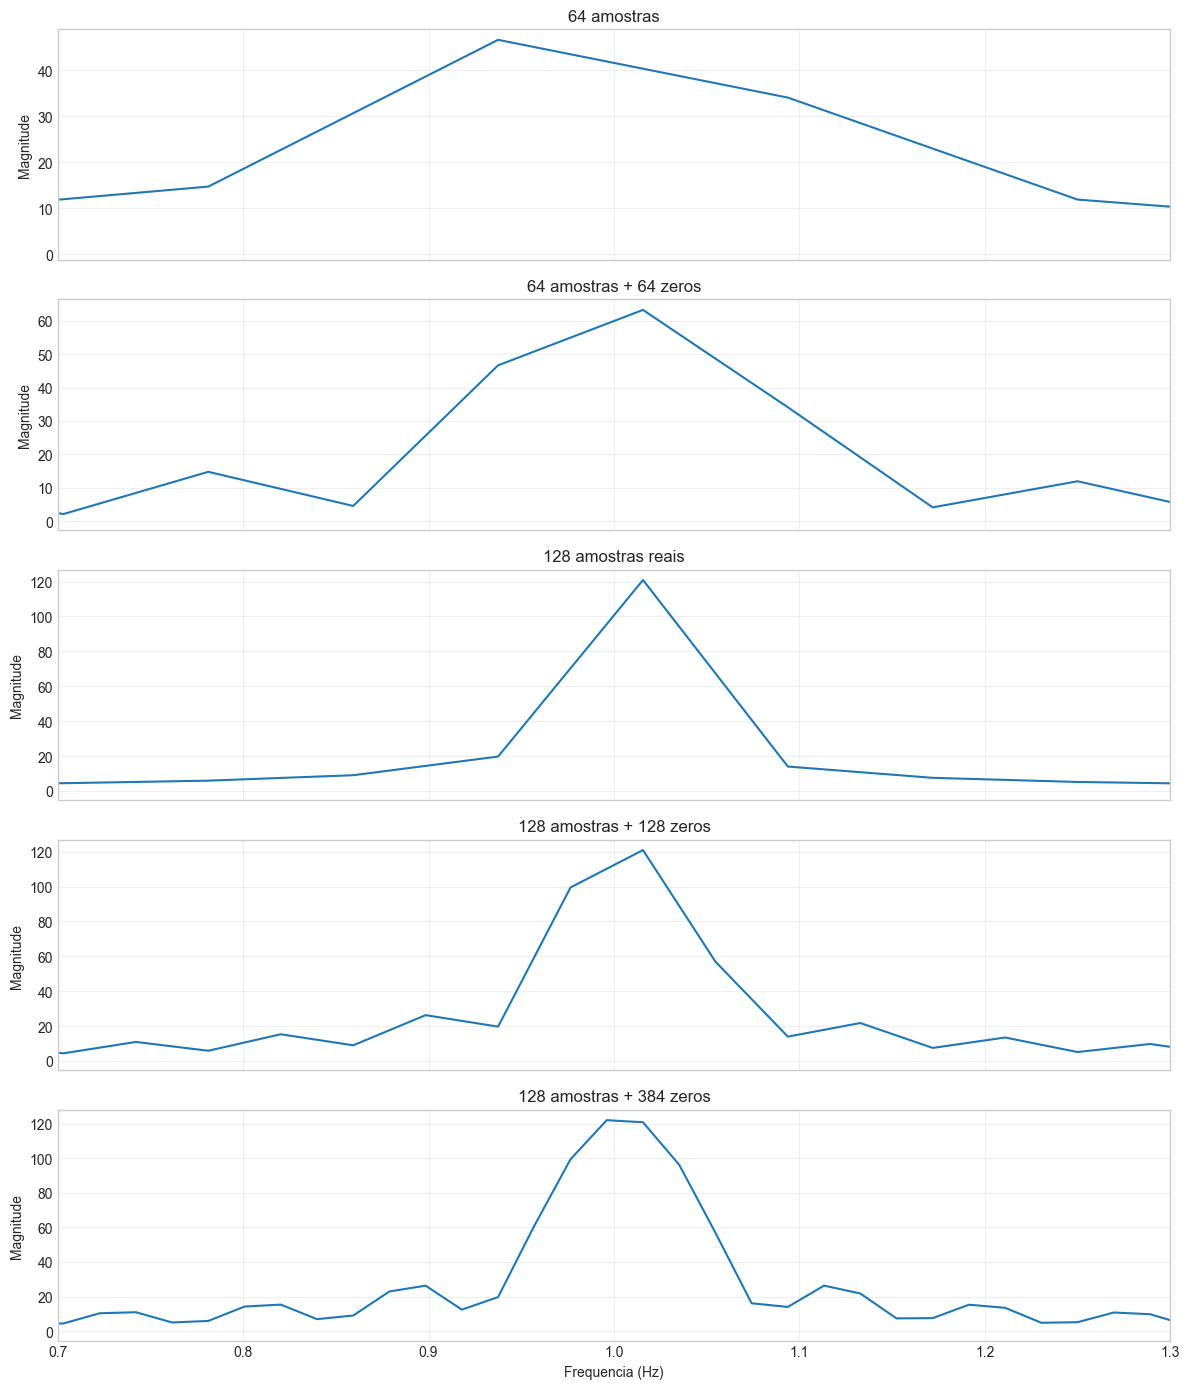

In [4]:
fig, axes = plt.subplots(len(configs), 1, figsize=(12, 14), sharex=True)

for ax, (label, _, _) in zip(axes, configs):
    f, mag = spectra[label]
    ax.plot(f, mag)
    ax.set_title(label)
    ax.set_ylabel('Magnitude')
    ax.set_xlim(0.7, 1.3)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frequencia (Hz)')
plt.tight_layout()
plt.show()


## Comentários

- O zero-padding interpola o espectro e deixa a curva mais suave, mas não cria nova informação.
- A resolução espectral real melhora quando o número de amostras efetivamente medidas aumenta.
- Por isso, `128` amostras reais distinguem melhor as senoides próximas do que `64` amostras com padding.
- Padding adicional ajuda na leitura visual do pico, mas não substitui maior duração de observação do sinal.
